# 03 Create Spatial Asset Layer

## Goal

This notebook converts the cleaned operational asset table into a geospatial asset layer.

The previous notebook created a cleaned dataset of operational renewable energy assets with valid `X-coordinate` and `Y-coordinate` values.

This notebook turns those coordinate fields into map points using GeoPandas.

The output is a GeoJSON file that can be used in later notebooks for mapping, spatial joins, distance calculations and exposure screening.

In [13]:
from pathlib import Path

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path("..").resolve()

DATA_INTERIM = PROJECT_ROOT / "data" / "interim"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
FIGURES = PROJECT_ROOT / "outputs" / "figures"

DATA_PROCESSED.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)

cleaned_csv_path = DATA_INTERIM / "operational_energy_assets_clean.csv"

assets = pd.read_csv(cleaned_csv_path)

print("Rows:", assets.shape[0])
print("Columns:", assets.shape[1])

assets.head()

Rows: 3058
Columns: 18


,Ref ID,Operator (or Applicant),Site Name,Technology Type,Installed Capacity (MWelec),Development Status,Development Status (short),County,Region,Country,Post Code,X-coordinate,Y-coordinate,Planning Authority,Under Construction,Operational,Solar Site Area (sqm),development_status_clean
0,3,Scottish and Southern Energy (SSE),Ferrybridge Multifuel 2 (FM2),EfW Incineration,70.0,Operational,Operational,West Yorkshire,Yorkshire and Humber,England,NaN,447490,424684,The Planning Inspectorate - National Infrastru...,01/09/2016,20/12/2019,NaN,operational
1,4,Energy Power Resources,Thetford Biomass Power Station,Biomass (dedicated),38.5,Operational,Operational,Norfolk,Eastern,England,NaN,585300,286900,Breckland,NaN,02/10/1998,NaN,operational
2,14,Dalkia,Chilton Energy Plant,Biomass (dedicated),18.0,Operational,Operational,County Durham,North East,England,NaN,428049,530414,County Durham,01/03/2010,12/03/2012,NaN,operational
3,22,Double H Nurseries,Double H Nurseries Biomass Plant,Biomass (dedicated),1.5,Operational,Operational,Hampshire,South East,England,BH25 5NQ,422804,94625,New Forest,NaN,15/12/2012,NaN,operational
4,23,REACT Energy (Kedco),Newry Biomass Phase 1 (Gasification),Advanced Conversion Technologies,2.0,Operational,Operational,Co. Down,Northern Ireland,Northern Ireland,NaN,117392,488885,"Newry, Mourne and Down",NaN,27/06/2012,NaN,operational


## From table to spatial layer

The cleaned dataset is currently a normal pandas DataFrame.

It contains coordinate columns, but Python does not yet understand those columns as geometry.

To perform geospatial analysis, I convert the table into a GeoDataFrame.

A GeoDataFrame is like a normal pandas DataFrame, but it contains a special `geometry` column. In this project, each geometry is a point representing the physical location of a renewable energy asset.

In [14]:
assets_gdf_27700 = gpd.GeoDataFrame(
    assets,
    geometry=gpd.points_from_xy(
        assets["X-coordinate"],
        assets["Y-coordinate"]
    ),
    crs="EPSG:27700"
)

print("Object type:", type(assets_gdf_27700))
print("CRS:", assets_gdf_27700.crs)
print("Rows:", len(assets_gdf_27700))

assets_gdf_27700[[
    "Site Name",
    "Technology Type",
    "Installed Capacity (MWelec)",
    "Region",
    "geometry"
]].head()

Object type: <class 'geopandas.geodataframe.GeoDataFrame'>
CRS: EPSG:27700
Rows: 3058


,Site Name,Technology Type,Installed Capacity (MWelec),Region,geometry
0,Ferrybridge Multifuel 2 (FM2),EfW Incineration,70.0,Yorkshire and Humber,POINT (447490 424684)
1,Thetford Biomass Power Station,Biomass (dedicated),38.5,Eastern,POINT (585300 286900)
2,Chilton Energy Plant,Biomass (dedicated),18.0,North East,POINT (428049 530414)
3,Double H Nurseries Biomass Plant,Biomass (dedicated),1.5,South East,POINT (422804 94625)
4,Newry Biomass Phase 1 (Gasification),Advanced Conversion Technologies,2.0,Northern Ireland,POINT (117392 488885)


## Why EPSG:27700 is used

The REPD dataset provides `X-coordinate` and `Y-coordinate` values using the British National Grid coordinate system.

This coordinate system is identified in Python as `EPSG:27700`.

A coordinate reference system, or CRS, tells Python how to interpret location values. Without a CRS, the numbers in the coordinate columns are just numbers. With the correct CRS, Python understands that each pair of coordinates represents a real location in Great Britain.

For this project, `EPSG:27700` is useful because it is designed for mapping Great Britain and supports distance calculations in metres.

This matters because later parts of the project may ask questions such as:

- how far an asset is from a boundary,
- whether an asset is near a hazard layer,
- which region an asset belongs to,
- where exposure may be geographically concentrated.

Using the correct CRS is important because distance-based exposure analysis depends on accurate spatial measurement.

In [15]:
print("Geometry types:")
print(assets_gdf_27700.geometry.geom_type.value_counts())

print("\nBounds:")
print(assets_gdf_27700.total_bounds)

Geometry types:
Point    3058
Name: count, dtype: int64

Bounds:
[   4942.   20706.  685500. 1198506.]


## First visual check

Before doing any exposure modelling, I plot the asset points as a basic quality check.

The purpose of this plot is not to produce a final map. It is to check whether the points form a sensible UK-shaped pattern.

If the CRS or coordinates were wrong, the points could appear in the wrong country, in a straight line, or in an unrealistic location.

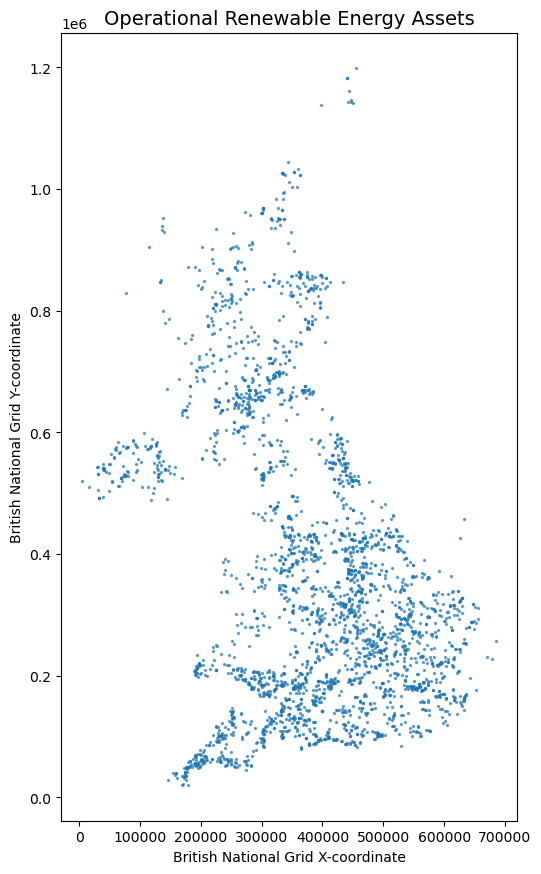

Saved figure to: /Users/oconnor/jaurice-market-notes/projects/physical-climate-risk-uk-energy/outputs/figures/operational_energy_assets_points.png


In [16]:
fig, ax = plt.subplots(figsize=(8, 9))

assets_gdf_27700.plot(
    ax=ax,
    markersize=2,
    alpha=0.6
)

ax.set_title("Operational Renewable Energy Assets", fontsize=14)
ax.set_xlabel("British National Grid X-coordinate")
ax.set_ylabel("British National Grid Y-coordinate")

plt.tight_layout()

figure_path = FIGURES / "operational_energy_assets_points.png"
plt.savefig(figure_path, dpi=200)

plt.show()

print("Saved figure to:", figure_path)

## Saving the spatial asset layer

The GeoDataFrame is saved as a GeoJSON file in the processed data folder.

This creates a reusable spatial asset layer. Later notebooks can load this GeoJSON directly instead of repeating the raw-data cleaning and coordinate-conversion steps.

In [17]:
processed_geojson_path = DATA_PROCESSED / "operational_energy_assets_27700.geojson"

assets_gdf_27700.to_file(processed_geojson_path, driver="GeoJSON")

print("Saved spatial asset layer to:")
print(processed_geojson_path)

Saved spatial asset layer to:
/Users/oconnor/jaurice-market-notes/projects/physical-climate-risk-uk-energy/data/processed/operational_energy_assets_27700.geojson


In [18]:
saved_assets = gpd.read_file(processed_geojson_path)

print("Rows:", len(saved_assets))
print("CRS:", saved_assets.crs)
print("Geometry types:")
print(saved_assets.geometry.geom_type.value_counts())

saved_assets.head()

Rows: 3058
CRS: EPSG:27700
Geometry types:
Point    3058
Name: count, dtype: int64


,Ref ID,Operator (or Applicant),Site Name,Technology Type,Installed Capacity (MWelec),Development Status,Development Status (short),County,Region,Country,Post Code,X-coordinate,Y-coordinate,Planning Authority,Under Construction,Operational,Solar Site Area (sqm),development_status_clean,geometry
0,3,Scottish and Southern Energy (SSE),Ferrybridge Multifuel 2 (FM2),EfW Incineration,70.0,Operational,Operational,West Yorkshire,Yorkshire and Humber,England,NaN,447490,424684,The Planning Inspectorate - National Infrastru...,01/09/2016,20/12/2019,NaN,operational,POINT (447490 424684)
1,4,Energy Power Resources,Thetford Biomass Power Station,Biomass (dedicated),38.5,Operational,Operational,Norfolk,Eastern,England,NaN,585300,286900,Breckland,NaN,02/10/1998,NaN,operational,POINT (585300 286900)
2,14,Dalkia,Chilton Energy Plant,Biomass (dedicated),18.0,Operational,Operational,County Durham,North East,England,NaN,428049,530414,County Durham,01/03/2010,12/03/2012,NaN,operational,POINT (428049 530414)
3,22,Double H Nurseries,Double H Nurseries Biomass Plant,Biomass (dedicated),1.5,Operational,Operational,Hampshire,South East,England,BH25 5NQ,422804,94625,New Forest,NaN,15/12/2012,NaN,operational,POINT (422804 94625)
4,23,REACT Energy (Kedco),Newry Biomass Phase 1 (Gasification),Advanced Conversion Technologies,2.0,Operational,Operational,Co. Down,Northern Ireland,Northern Ireland,NaN,117392,488885,"Newry, Mourne and Down",NaN,27/06/2012,NaN,operational,POINT (117392 488885)
